In [2]:
# MODEL FOR SEMENTIC INPAINTING

import torch
import torch.nn as nn


class _netG(nn.Module):
    def __init__(self, opt):
        super(_netG, self).__init__()
        self.ngpu = opt.ngpu
        self.main = nn.Sequential(
            # input is (nc) x 128 x 128
            nn.Conv2d(opt.nc,opt.nef,4,2,1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # state size: (nef) x 64 x 64
            nn.Conv2d(opt.nef,opt.nef,4,2,1, bias=False),
            nn.BatchNorm2d(opt.nef),
            nn.LeakyReLU(0.2, inplace=True),
            # state size: (nef) x 32 x 32
            nn.Conv2d(opt.nef,opt.nef*2,4,2,1, bias=False),
            nn.BatchNorm2d(opt.nef*2),
            nn.LeakyReLU(0.2, inplace=True),
            # state size: (nef*2) x 16 x 16
            nn.Conv2d(opt.nef*2,opt.nef*4,4,2,1, bias=False),
            nn.BatchNorm2d(opt.nef*4),
            nn.LeakyReLU(0.2, inplace=True),
            # state size: (nef*4) x 8 x 8
            nn.Conv2d(opt.nef*4,opt.nef*8,4,2,1, bias=False),
            nn.BatchNorm2d(opt.nef*8),
            nn.LeakyReLU(0.2, inplace=True),
            # state size: (nef*8) x 4 x 4
            nn.Conv2d(opt.nef*8,opt.nBottleneck,4, bias=False),
            # tate size: (nBottleneck) x 1 x 1
            nn.BatchNorm2d(opt.nBottleneck),
            nn.LeakyReLU(0.2, inplace=True),
            # input is Bottleneck, going into a convolution
            nn.ConvTranspose2d(opt.nBottleneck, opt.ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(opt.ngf * 8),
            nn.ReLU(True),
            # state size. (ngf*8) x 4 x 4
            nn.ConvTranspose2d(opt.ngf * 8, opt.ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(opt.ngf * 4),
            nn.ReLU(True),
            # state size. (ngf*4) x 8 x 8
            nn.ConvTranspose2d(opt.ngf * 4, opt.ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(opt.ngf * 2),
            nn.ReLU(True),
            # state size. (ngf*2) x 16 x 16
            nn.ConvTranspose2d(opt.ngf * 2, opt.ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(opt.ngf),
            nn.ReLU(True),
            # state size. (ngf) x 32 x 32
            nn.ConvTranspose2d(opt.ngf, opt.nc, 4, 2, 1, bias=False),
            nn.Tanh()
            # state size. (nc) x 64 x 64
        )

    def forward(self, input):
        if isinstance(input.data, torch.cuda.FloatTensor) and self.ngpu > 1:
            output = nn.parallel.data_parallel(self.main, input, range(self.ngpu))
        else:
            output = self.main(input)
        return output


class _netlocalD(nn.Module):
    def __init__(self, opt):
        super(_netlocalD, self).__init__()
        self.ngpu = opt.ngpu
        self.main = nn.Sequential(
            # input is (nc) x 64 x 64
            nn.Conv2d(opt.nc, opt.ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf) x 32 x 32
            nn.Conv2d(opt.ndf, opt.ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(opt.ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*2) x 16 x 16
            nn.Conv2d(opt.ndf * 2, opt.ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(opt.ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*4) x 8 x 8
            nn.Conv2d(opt.ndf * 4, opt.ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(opt.ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*8) x 4 x 4
            nn.Conv2d(opt.ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
            # final : 1 X 1 X 1
        )

    def forward(self, input):
        if isinstance(input.data, torch.cuda.FloatTensor) and self.ngpu > 1:
            output = nn.parallel.data_parallel(self.main, input, range(self.ngpu))
        else:
            output = self.main(input)

        return output.view(-1)
        # .view(-1,1) : [batch_size X 1 X 1 x 1] --> [batch_size]

In [2]:
# Creating directories : 

import os

try : 
    os.makedirs("result/train/cropped")
    os.makedirs("result/train/real")
    os.makedirs("result/test/recon")
    os.makedirs("models")
except OSError : 
    pass

In [3]:
# Random Seed Initialization : 
import random
seed = random.randint(1,10000)
print(f"Random seed is : {seed}")

print(f"GPU availability : {torch.cuda.is_available()}")

torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)


Random seed is : 3016
GPU availability : True


In [4]:
target_dir = "datasets/train"

In [5]:
# Downloading the dataset

'''
I am using CelebA dataset, you can choose any dataset as you wish 
'''
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")
print("Path to dataset files:", path)



/home/vasu-choudhari/llm_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/vasu-choudhari/.cache/kagglehub/datasets/jessicali9530/celeba-dataset/versions/2


In [ ]:
import os
import shutil
from glob import glob

images_path = os.path.join(path, 'img_align_celeba/img_align_celeba')
target_dir = "datasets/train"
os.makedirs(target_dir, exist_ok=True)
celeb_images = os.path.join(target_dir, "celeba")
os.makedirs(celeb_images, exist_ok=True)


if os.path.exists(images_path):
    image_files = glob(os.path.join(images_path, '*'))
    
    print(f"Found {len(image_files)} files to copy")
    
    for i, source_file in enumerate(image_files):
        if i % 1000 == 0:
            print(f"Copied {i}/{len(image_files)} files...")
        
        filename = os.path.basename(source_file)
        destination = os.path.join(celeb_images, filename)
        shutil.copy2(source_file, destination)
    
    print(f"Successfully copied all images to {celeb_images}")

In [9]:
# Creating Dataset and DataLoader : 
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
img_transfrom = transforms.Compose([
    transforms.Resize(size=(128,128)),
    transforms.CenterCrop(size=(128,128)),
    transforms.ToTensor(), # (0,255) -> (0,1.0) int -> float
    transforms.Normalize(mean=(0.5,0.5,0.5),std=(0.5, 0.5,0.5)) # (0,1) --> (-1,1) # commanly used in gans
])



In [ ]:
# Creating Dataset and DataLoader : 
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
dataset = datasets.ImageFolder(root=target_dir, transform=img_transfrom)
data_loader =  DataLoader(dataset, num_workers=2, shuffle=True, batch_size=64)

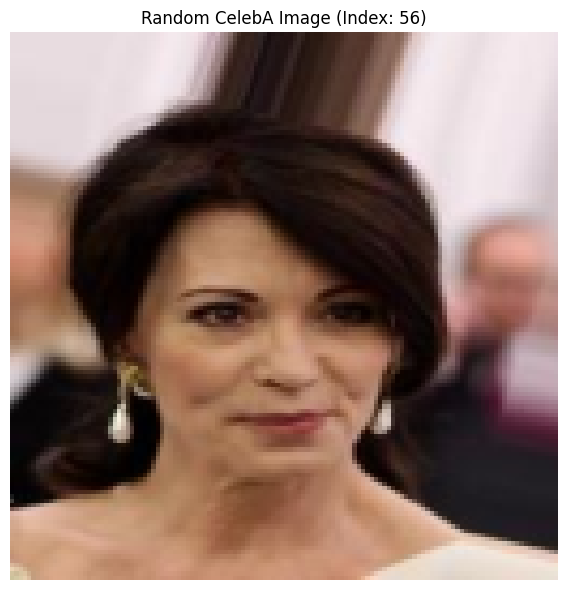

In [7]:
import matplotlib.pyplot as plt
import random
import torch

def get_random_image():
    batch_data, batch_label = next(iter(data_loader))
    random_number = random.randint(0, len(batch_data)-1)
    random_image = batch_data[random_number]
    
    # Convert from tensor format for display
    # From: (C, H, W) with range [-1, 1]
    # To: (H, W, C) with range [0, 1]
    
    # Denormalize: reverse the normalization (x - 0.5) / 0.5 -> x * 0.5 + 0.5
    denormalized_image = random_image * 0.5 + 0.5 # (-1,1) -> (0,1)
    
    # Convert from (C, H, W) to (H, W, C) for matplotlib
    display_image = denormalized_image.permute(1, 2, 0)
    
    # Clamp values to [0, 1] range (in case of small floating point errors)
    display_image = torch.clamp(display_image, 0, 1)
    
    # Display the image
    plt.figure(figsize=(6, 6))
    plt.imshow(display_image)
    plt.axis('off')  # Remove axes
    plt.title(f'Random CelebA Image (Index: {random_number})')
    plt.tight_layout()
    plt.show()
    
    return random_image, random_number

# Call the function
random_image, index = get_random_image()

In [19]:
import argparse

opt = {
    "ngpu" : int(1),
    "ngf" : int(64),
    "ndf" : int(64),
    "nc" : int(3),
    "lr" : float(0.0002),
    "beta1" : float(0.5),
    "nBottleneck" : int(4000),
    "nef" : int(64),
    "wtl2" : float(0.998),
    "wtlD" : float(0.001),
    "overlapL2Weight" : 10,
    "batchSize" : int(64),
    "imageSize" : int(128),
    "overlap" : int(4)
}

opt = argparse.Namespace(**opt)


In [9]:
# initializing models with custom weights

def weight_init(m) : 
    classname = m.__class__.__name__
    with torch.no_grad() : 
        if classname.find('Conv') != -1 :
            m.weight.normal_(0.0, 0.02) #(mean, std)
        elif classname.find('BatchNorm') != -1 :
            m.weight.normal_(1.0, 0.02) # (mean, std)
            m.bias.data.fill_(0)

netG = _netG(opt)
netG.apply(weight_init)

netD = _netlocalD(opt)
netD.apply(weight_init)

_netlocalD(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (12): Sigmoid()
  )
)

In [10]:
criterion = nn.BCELoss()
criterionMSE = nn.MSELoss()
input_real = torch.FloatTensor(opt.batchSize, 3, opt.imageSize, opt.imageSize)
input_cropped = torch.FloatTensor(opt.batchSize, 3, opt.imageSize, opt.imageSize)
label = torch.FloatTensor(opt.batchSize)
real_label = 1.0
fake_label = 0.0
real_center = torch.FloatTensor(opt.batchSize, 3, (opt.imageSize)//2, (opt.imageSize)//2)

In [11]:
# Setting up the device : 
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device found : ", device)
if device == "cuda" : 
    criterion.to(device)
    criterionMSE.to(device)
    netD.to(device)
    netG.to(device)
    input_real, input_cropped, label = input_real.to(device), input_cropped.to(device), label.to(device)
    real_center = real_center.to(device)

print("All components moved to device successfully")

Device found :  cuda
All components moved to device successfully


In [12]:
# setup optimizer
import torch.optim as optim
optimizerD = optim.Adam(netD.parameters(), lr=opt.lr, betas=(opt.beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=opt.lr, betas=(opt.beta1, 0.999))

print("Optimizers set up successfully")

Optimizers set up successfully


In [13]:
# Training loop : 
import torchvision.utils as vutils
epochs = 5
G_losses = []
D_losses = []
G_D_losses = []  # Adversarial loss component
G_L2_losses = []  # L2 loss component


for epoch in range(epochs) :
    epoch_G_loss = 0
    epoch_D_loss = 0
    epoch_G_D_loss = 0
    epoch_G_L2_loss = 0
    num_batches = 0
    for i, data in enumerate(data_loader, 0) : 
        real_cpu, _ = data # Uncropped real data
        real_center_cpu = real_cpu[:, :, opt.imageSize//4 : opt.imageSize//4 + opt.imageSize//2, opt.imageSize//4 : opt.imageSize//4 + opt.imageSize//2]
        # real_center_cpu is centre real data
        batch_size = real_cpu.shape[0]

        # Copying into our tensors
        input_real.data.resize_(real_cpu.size()).copy_(real_cpu) # real unmasked image
        input_cropped.data.resize_(real_cpu.size()).copy_(real_cpu) # real masked image
        real_center.data.resize_(real_center_cpu.size()).copy_(real_center_cpu) # real centre part

        # Masking : 
        input_cropped.data[:, 0, opt.imageSize//4 + opt.overlap : opt.imageSize// 4 + opt.imageSize // 2 - opt.overlap, opt.imageSize//4 + opt.overlap : opt.imageSize// 4 + opt.imageSize // 2 - opt.overlap] = 2*117.0/255 - 1.0
        input_cropped.data[:, 1, opt.imageSize//4 + opt.overlap : opt.imageSize// 4 + opt.imageSize // 2 - opt.overlap, opt.imageSize//4 + opt.overlap : opt.imageSize// 4 + opt.imageSize // 2 - opt.overlap] = 2*104.0/255 - 1.0
        input_cropped.data[:, 2, opt.imageSize//4 + opt.overlap : opt.imageSize// 4 + opt.imageSize // 2 - opt.overlap, opt.imageSize//4 + opt.overlap : opt.imageSize// 4 + opt.imageSize // 2 - opt.overlap] = 2*123.0/255 - 1.0

        # we filled the center part with gray color of the 3 channels
        # we are actually predicting some less pixels (4 px less from each side)

        # Updating Discriminator : 
        # train with real image
        netD.zero_grad()
        label.data.resize_(batch_size).fill_(real_label)

        output = netD(real_center)
        errD_real = criterion(output, label) # BCE Loss
        errD_real.backward()
        D_x = output.data.mean()

        # train with fake image : 
        fake = netG(input_cropped) # the generator only generates masked region
        # i.e fake is [batch, channels, 64, 64]
        label.data.fill_(fake_label)
        output = netD(fake.detach()) # we use fake.detach() because if not used : 
        '''
        Gradients would flow back through:
        err D_fake → netD → fake → netG, 
        This would accidentally update the Generator during Discriminator training!
        '''
        errD_fake = criterion(output, label) #BCE loss
        errD_fake.backward()
        D_G_z1 = output.data.mean()

        errD = errD_fake + errD_real
        optimizerD.step()

        # Updating Context Encoder / Generator : 
        netG.zero_grad()
        label.data.fill_(real_label) # fake labels are real for generator cost
        output = netD(fake)
        errG_D = criterion(output, label) # this is adversial loss

        # wtl2
        wtl2Matrix = real_center.clone() # [batch, 3, 64,64]
        wtl2Matrix.data.fill_(opt.wtl2*10)
        wtl2Matrix.data[:, :, opt.overlap : opt.imageSize // 2 - opt.overlap,  opt.overlap : opt.imageSize // 2 - opt.overlap] = opt.wtl2

        # weight matrix : 
        # kept weights higher for the border to make the blending smooth
        '''
        [99.8  99.8  99.8  99.8  99.8  99.8]
        [99.8  0.99  0.99  0.99  0.99  99.8]
        [99.8  0.99  0.99  0.99  0.99  99.8]
        [99.8  0.99  0.99  0.99  0.99  99.8]
        [99.8  0.99  0.99  0.99  0.99  99.8]
        [99.8  99.8  99.8  99.8  99.8  99.8]

        '''

        errG_l2 = (fake - real_center).pow(2)
        errG_l2 = errG_l2 * wtl2Matrix
        errG_l2 = errG_l2.mean() # this is l2 weighted error

        errG = (1 - opt.wtl2) * errG_D + opt.wtl2 * errG_l2 # this is joint error
        errG.backward()

        D_G_z2 = output.data.mean()
        optimizerG.step()
        
        epoch_G_loss += errG.item()
        epoch_D_loss += errD.item()
        epoch_G_D_loss += errG_D.item()
        epoch_G_L2_loss += errG_l2.item()
        num_batches += 1

        print('[%d/%d][%d/%d] Loss_D: %.4f Loss_G: %.4f / %.4f l_D(x): %.4f l_D(G(z)): %.4f'
                  % (epoch, epochs, i, len(data_loader),
                     errD.item(), errG_D.item(),errG_l2.item(), D_x,D_G_z1, ))
        if i % 100 == 0:
            with torch.no_grad():  # Disable gradients for inference
                # Save original images
                vutils.save_image(real_cpu, 
                    f'result/train/real/real_samples_epoch_{epoch:03d}_iter_{i:04d}.png',
                    normalize=True, nrow=8)

                # Save input (with holes)
                vutils.save_image(input_cropped, 
                    f'result/train/cropped/cropped_samples_epoch_{epoch:03d}_iter_{i:04d}.png',
                    normalize=True, nrow=8)

                # Create and save reconstruction
                recon_image = input_cropped.clone()
                recon_image[:, :, 32:96, 32:96] = fake  # Use integer division
                vutils.save_image(recon_image,
                    f'result/train/recon/recon_samples_epoch_{epoch:03d}_iter_{i:04d}.png', 
                    normalize=True, nrow=8)
     
    G_losses.append(epoch_G_loss / num_batches)
    D_losses.append(epoch_D_loss / num_batches)
    G_D_losses.append(epoch_G_D_loss / num_batches)
    G_L2_losses.append(epoch_G_L2_loss / num_batches)
    torch.save({'epoch':epoch+1,
                'state_dict':netG.state_dict()},
                'model/netG_streetview.pth' )
    torch.save({'epoch':epoch+1,
                'state_dict':netD.state_dict()},
                'model/netlocalD.pth' )

[0/5][0/3166] Loss_D: 2.0763 Loss_G: 4.7841 / 0.9454 l_D(x): 0.3201 l_D(G(z)): 0.4876
[0/5][1/3166] Loss_D: 2.7895 Loss_G: 6.0806 / 0.9236 l_D(x): 0.9880 l_D(G(z)): 0.9129
[0/5][2/3166] Loss_D: 1.7186 Loss_G: 8.4733 / 0.8995 l_D(x): 0.9324 l_D(G(z)): 0.7198
[0/5][3/3166] Loss_D: 0.5583 Loss_G: 8.4035 / 0.7845 l_D(x): 0.9254 l_D(G(z)): 0.3253
[0/5][4/3166] Loss_D: 0.8560 Loss_G: 8.3767 / 0.7463 l_D(x): 0.8134 l_D(G(z)): 0.3135
[0/5][5/3166] Loss_D: 0.7451 Loss_G: 9.1491 / 0.6749 l_D(x): 0.8266 l_D(G(z)): 0.3193
[0/5][6/3166] Loss_D: 0.8316 Loss_G: 9.8467 / 0.6790 l_D(x): 0.8153 l_D(G(z)): 0.2984
[0/5][7/3166] Loss_D: 0.5065 Loss_G: 8.3621 / 0.5638 l_D(x): 0.8246 l_D(G(z)): 0.1587
[0/5][8/3166] Loss_D: 1.1535 Loss_G: 11.4637 / 0.6058 l_D(x): 0.8207 l_D(G(z)): 0.3952
[0/5][9/3166] Loss_D: 0.6627 Loss_G: 7.9091 / 0.5552 l_D(x): 0.7220 l_D(G(z)): 0.1063
[0/5][10/3166] Loss_D: 0.9317 Loss_G: 12.0306 / 0.5230 l_D(x): 0.9356 l_D(G(z)): 0.3540
[0/5][11/3166] Loss_D: 0.4111 Loss_G: 9.8518 / 0.45

[0/5][95/3166] Loss_D: 0.3122 Loss_G: 3.5500 / 0.1928 l_D(x): 0.8761 l_D(G(z)): 0.1465
[0/5][96/3166] Loss_D: 0.1757 Loss_G: 3.6885 / 0.1686 l_D(x): 0.9034 l_D(G(z)): 0.0528
[0/5][97/3166] Loss_D: 0.1821 Loss_G: 2.9523 / 0.1818 l_D(x): 0.8897 l_D(G(z)): 0.0419
[0/5][98/3166] Loss_D: 0.4181 Loss_G: 5.0518 / 0.1564 l_D(x): 0.9440 l_D(G(z)): 0.2726
[0/5][99/3166] Loss_D: 0.7527 Loss_G: 1.2441 / 0.1577 l_D(x): 0.6037 l_D(G(z)): 0.0282
[0/5][100/3166] Loss_D: 0.4179 Loss_G: 3.9812 / 0.1450 l_D(x): 0.9466 l_D(G(z)): 0.2686
[0/5][101/3166] Loss_D: 0.5183 Loss_G: 2.9664 / 0.1542 l_D(x): 0.7551 l_D(G(z)): 0.1002
[0/5][102/3166] Loss_D: 0.2532 Loss_G: 3.7882 / 0.1906 l_D(x): 0.9429 l_D(G(z)): 0.1300
[0/5][103/3166] Loss_D: 0.3163 Loss_G: 4.6427 / 0.1913 l_D(x): 0.9493 l_D(G(z)): 0.2113
[0/5][104/3166] Loss_D: 0.4977 Loss_G: 2.2821 / 0.1684 l_D(x): 0.7088 l_D(G(z)): 0.0299
[0/5][105/3166] Loss_D: 0.1546 Loss_G: 2.8468 / 0.1792 l_D(x): 0.9665 l_D(G(z)): 0.1047
[0/5][106/3166] Loss_D: 0.3332 Loss_G

[0/5][189/3166] Loss_D: 0.4916 Loss_G: 5.7932 / 0.1287 l_D(x): 0.9784 l_D(G(z)): 0.3493
[0/5][190/3166] Loss_D: 0.0818 Loss_G: 6.7696 / 0.1461 l_D(x): 0.9389 l_D(G(z)): 0.0090
[0/5][191/3166] Loss_D: 0.2902 Loss_G: 3.8292 / 0.1489 l_D(x): 0.7953 l_D(G(z)): 0.0077
[0/5][192/3166] Loss_D: 0.1516 Loss_G: 3.2406 / 0.1293 l_D(x): 0.9700 l_D(G(z)): 0.1090
[0/5][193/3166] Loss_D: 0.2981 Loss_G: 4.7338 / 0.1311 l_D(x): 0.9269 l_D(G(z)): 0.1800
[0/5][194/3166] Loss_D: 0.2845 Loss_G: 3.2647 / 0.1277 l_D(x): 0.8155 l_D(G(z)): 0.0316
[0/5][195/3166] Loss_D: 0.1877 Loss_G: 3.8197 / 0.1272 l_D(x): 0.9629 l_D(G(z)): 0.1299
[0/5][196/3166] Loss_D: 0.2087 Loss_G: 5.3051 / 0.1407 l_D(x): 0.9689 l_D(G(z)): 0.1455
[0/5][197/3166] Loss_D: 0.2282 Loss_G: 5.2695 / 0.1556 l_D(x): 0.8904 l_D(G(z)): 0.0098
[0/5][198/3166] Loss_D: 0.3384 Loss_G: 3.7519 / 0.1389 l_D(x): 0.8870 l_D(G(z)): 0.1615
[0/5][199/3166] Loss_D: 0.5252 Loss_G: 2.1540 / 0.1391 l_D(x): 0.7591 l_D(G(z)): 0.1404
[0/5][200/3166] Loss_D: 0.4089 L

[0/5][283/3166] Loss_D: 0.1309 Loss_G: 3.0544 / 0.1230 l_D(x): 0.9838 l_D(G(z)): 0.1002
[0/5][284/3166] Loss_D: 0.5134 Loss_G: 6.2992 / 0.1198 l_D(x): 0.9928 l_D(G(z)): 0.3553
[0/5][285/3166] Loss_D: 0.2129 Loss_G: 6.1766 / 0.1266 l_D(x): 0.8515 l_D(G(z)): 0.0102
[0/5][286/3166] Loss_D: 1.4601 Loss_G: 0.2884 / 0.1253 l_D(x): 0.3964 l_D(G(z)): 0.0253
[0/5][287/3166] Loss_D: 1.5462 Loss_G: 6.6505 / 0.1222 l_D(x): 0.9903 l_D(G(z)): 0.6603
[0/5][288/3166] Loss_D: 0.1442 Loss_G: 7.1138 / 0.1296 l_D(x): 0.8892 l_D(G(z)): 0.0090
[0/5][289/3166] Loss_D: 0.5092 Loss_G: 3.5481 / 0.1212 l_D(x): 0.6771 l_D(G(z)): 0.0070
[0/5][290/3166] Loss_D: 0.3134 Loss_G: 1.8501 / 0.1163 l_D(x): 0.8808 l_D(G(z)): 0.1270
[0/5][291/3166] Loss_D: 0.2922 Loss_G: 5.0135 / 0.1305 l_D(x): 0.9924 l_D(G(z)): 0.2244
[0/5][292/3166] Loss_D: 0.2164 Loss_G: 4.2105 / 0.1067 l_D(x): 0.8660 l_D(G(z)): 0.0442
[0/5][293/3166] Loss_D: 0.2304 Loss_G: 4.5058 / 0.1299 l_D(x): 0.9789 l_D(G(z)): 0.1753
[0/5][294/3166] Loss_D: 0.6337 L

[0/5][377/3166] Loss_D: 0.8077 Loss_G: 7.1976 / 0.1137 l_D(x): 0.9551 l_D(G(z)): 0.4862
[0/5][378/3166] Loss_D: 0.8188 Loss_G: 4.1820 / 0.1205 l_D(x): 0.5303 l_D(G(z)): 0.0050
[0/5][379/3166] Loss_D: 0.2491 Loss_G: 2.0986 / 0.1150 l_D(x): 0.8913 l_D(G(z)): 0.0890
[0/5][380/3166] Loss_D: 0.3407 Loss_G: 4.0530 / 0.1133 l_D(x): 0.9643 l_D(G(z)): 0.2392
[0/5][381/3166] Loss_D: 0.0622 Loss_G: 5.4242 / 0.1255 l_D(x): 0.9718 l_D(G(z)): 0.0313
[0/5][382/3166] Loss_D: 0.1185 Loss_G: 4.5014 / 0.1374 l_D(x): 0.9789 l_D(G(z)): 0.0822
[0/5][383/3166] Loss_D: 0.3269 Loss_G: 2.4362 / 0.1162 l_D(x): 0.7998 l_D(G(z)): 0.0500
[0/5][384/3166] Loss_D: 0.3083 Loss_G: 3.9926 / 0.1073 l_D(x): 0.9519 l_D(G(z)): 0.2075
[0/5][385/3166] Loss_D: 0.4547 Loss_G: 2.5461 / 0.1253 l_D(x): 0.7780 l_D(G(z)): 0.1250
[0/5][386/3166] Loss_D: 0.2115 Loss_G: 3.3792 / 0.1149 l_D(x): 0.9339 l_D(G(z)): 0.1135
[0/5][387/3166] Loss_D: 0.3661 Loss_G: 2.3830 / 0.1152 l_D(x): 0.8113 l_D(G(z)): 0.0945
[0/5][388/3166] Loss_D: 0.1798 L

...

[2/5][1847/3166] Loss_D: 0.6222 Loss_G: 2.0613 / 0.0643 l_D(x): 0.6289 l_D(G(z)): 0.0870
[2/5][1848/3166] Loss_D: 0.8730 Loss_G: 4.9030 / 0.0763 l_D(x): 0.9804 l_D(G(z)): 0.5117
[2/5][1849/3166] Loss_D: 0.4182 Loss_G: 4.1457 / 0.0682 l_D(x): 0.7031 l_D(G(z)): 0.0228
[2/5][1850/3166] Loss_D: 0.2714 Loss_G: 3.0405 / 0.0730 l_D(x): 0.9153 l_D(G(z)): 0.1468
[2/5][1851/3166] Loss_D: 0.2737 Loss_G: 3.2350 / 0.0764 l_D(x): 0.8769 l_D(G(z)): 0.1165
[2/5][1852/3166] Loss_D: 0.8708 Loss_G: 1.1355 / 0.0659 l_D(x): 0.5475 l_D(G(z)): 0.1175
[2/5][1853/3166] Loss_D: 0.9813 Loss_G: 1.3481 / 0.0608 l_D(x): 0.6529 l_D(G(z)): 0.3456
[2/5][1854/3166] Loss_D: 0.4096 Loss_G: 2.9717 / 0.0630 l_D(x): 0.8978 l_D(G(z)): 0.2346
[2/5][1855/3166] Loss_D: 0.3178 Loss_G: 3.1570 / 0.0589 l_D(x): 0.8648 l_D(G(z)): 0.1392
[2/5][1856/3166] Loss_D: 0.1961 Loss_G: 3.3293 / 0.0685 l_D(x): 0.9051 l_D(G(z)): 0.0831
[2/5][1857/3166] Loss_D: 0.4545 Loss_G: 4.2518 / 0.0657 l_D(x): 0.9535 l_D(G(z)): 0.2898
[2/5][1858/3166] Loss

[2/5][1941/3166] Loss_D: 1.6009 Loss_G: 0.1400 / 0.0646 l_D(x): 0.2769 l_D(G(z)): 0.0454
[2/5][1942/3166] Loss_D: 2.6460 Loss_G: 4.1713 / 0.0625 l_D(x): 0.9971 l_D(G(z)): 0.8783
[2/5][1943/3166] Loss_D: 0.1374 Loss_G: 4.9706 / 0.0677 l_D(x): 0.9743 l_D(G(z)): 0.0973
[2/5][1944/3166] Loss_D: 0.3386 Loss_G: 2.9272 / 0.0609 l_D(x): 0.7692 l_D(G(z)): 0.0306
[2/5][1945/3166] Loss_D: 0.2921 Loss_G: 4.3264 / 0.0681 l_D(x): 0.9778 l_D(G(z)): 0.2151
[2/5][1946/3166] Loss_D: 1.0234 Loss_G: 0.3771 / 0.0616 l_D(x): 0.4423 l_D(G(z)): 0.0360
[2/5][1947/3166] Loss_D: 1.2743 Loss_G: 7.0155 / 0.0625 l_D(x): 0.9934 l_D(G(z)): 0.6515
[2/5][1948/3166] Loss_D: 1.3671 Loss_G: 2.9167 / 0.0613 l_D(x): 0.3302 l_D(G(z)): 0.0047
[2/5][1949/3166] Loss_D: 0.1530 Loss_G: 1.9978 / 0.0657 l_D(x): 0.9555 l_D(G(z)): 0.0969
[2/5][1950/3166] Loss_D: 0.7250 Loss_G: 4.4761 / 0.0666 l_D(x): 0.9812 l_D(G(z)): 0.4364
[2/5][1951/3166] Loss_D: 0.2012 Loss_G: 4.5270 / 0.0690 l_D(x): 0.9024 l_D(G(z)): 0.0833
[2/5][1952/3166] Loss

[2/5][2035/3166] Loss_D: 0.5258 Loss_G: 2.0473 / 0.0516 l_D(x): 0.8041 l_D(G(z)): 0.2194
[2/5][2036/3166] Loss_D: 0.5641 Loss_G: 4.5795 / 0.0719 l_D(x): 0.9888 l_D(G(z)): 0.3855
[2/5][2037/3166] Loss_D: 0.6265 Loss_G: 2.6697 / 0.0624 l_D(x): 0.6482 l_D(G(z)): 0.1031
[2/5][2038/3166] Loss_D: 0.4777 Loss_G: 2.2931 / 0.0570 l_D(x): 0.7784 l_D(G(z)): 0.1419
[2/5][2039/3166] Loss_D: 0.6797 Loss_G: 3.3682 / 0.0626 l_D(x): 0.8865 l_D(G(z)): 0.3695
[2/5][2040/3166] Loss_D: 0.5075 Loss_G: 3.4110 / 0.0618 l_D(x): 0.8121 l_D(G(z)): 0.2084
[2/5][2041/3166] Loss_D: 1.1117 Loss_G: 0.8906 / 0.0571 l_D(x): 0.4432 l_D(G(z)): 0.0963
[2/5][2042/3166] Loss_D: 1.0463 Loss_G: 3.9305 / 0.0695 l_D(x): 0.9817 l_D(G(z)): 0.5721
[2/5][2043/3166] Loss_D: 0.5950 Loss_G: 3.0055 / 0.0747 l_D(x): 0.6429 l_D(G(z)): 0.0723
[2/5][2044/3166] Loss_D: 0.1776 Loss_G: 3.0630 / 0.0680 l_D(x): 0.8904 l_D(G(z)): 0.0507
[2/5][2045/3166] Loss_D: 0.2925 Loss_G: 2.8476 / 0.0679 l_D(x): 0.9162 l_D(G(z)): 0.1636
[2/5][2046/3166] Loss

[2/5][2129/3166] Loss_D: 0.1634 Loss_G: 4.2832 / 0.0750 l_D(x): 0.9653 l_D(G(z)): 0.1147
[2/5][2130/3166] Loss_D: 0.5435 Loss_G: 2.1293 / 0.0703 l_D(x): 0.6733 l_D(G(z)): 0.0936
[2/5][2131/3166] Loss_D: 0.3433 Loss_G: 3.0334 / 0.0737 l_D(x): 0.9272 l_D(G(z)): 0.2054
[2/5][2132/3166] Loss_D: 1.4345 Loss_G: 0.3059 / 0.0683 l_D(x): 0.3396 l_D(G(z)): 0.1214
[2/5][2133/3166] Loss_D: 0.6265 Loss_G: 3.3604 / 0.0594 l_D(x): 0.9837 l_D(G(z)): 0.4060
[2/5][2134/3166] Loss_D: 0.1877 Loss_G: 4.3648 / 0.0667 l_D(x): 0.9758 l_D(G(z)): 0.1350
[2/5][2135/3166] Loss_D: 0.2666 Loss_G: 3.8721 / 0.0730 l_D(x): 0.9016 l_D(G(z)): 0.1313
[2/5][2136/3166] Loss_D: 0.2808 Loss_G: 3.1243 / 0.0638 l_D(x): 0.8136 l_D(G(z)): 0.0518
[2/5][2137/3166] Loss_D: 0.8346 Loss_G: 0.8266 / 0.0685 l_D(x): 0.5697 l_D(G(z)): 0.1518
[2/5][2138/3166] Loss_D: 1.0522 Loss_G: 4.9969 / 0.0689 l_D(x): 0.9754 l_D(G(z)): 0.5754
[2/5][2139/3166] Loss_D: 0.1876 Loss_G: 5.0010 / 0.0669 l_D(x): 0.8721 l_D(G(z)): 0.0353
[2/5][2140/3166] Loss

KeyboardInterrupt: 

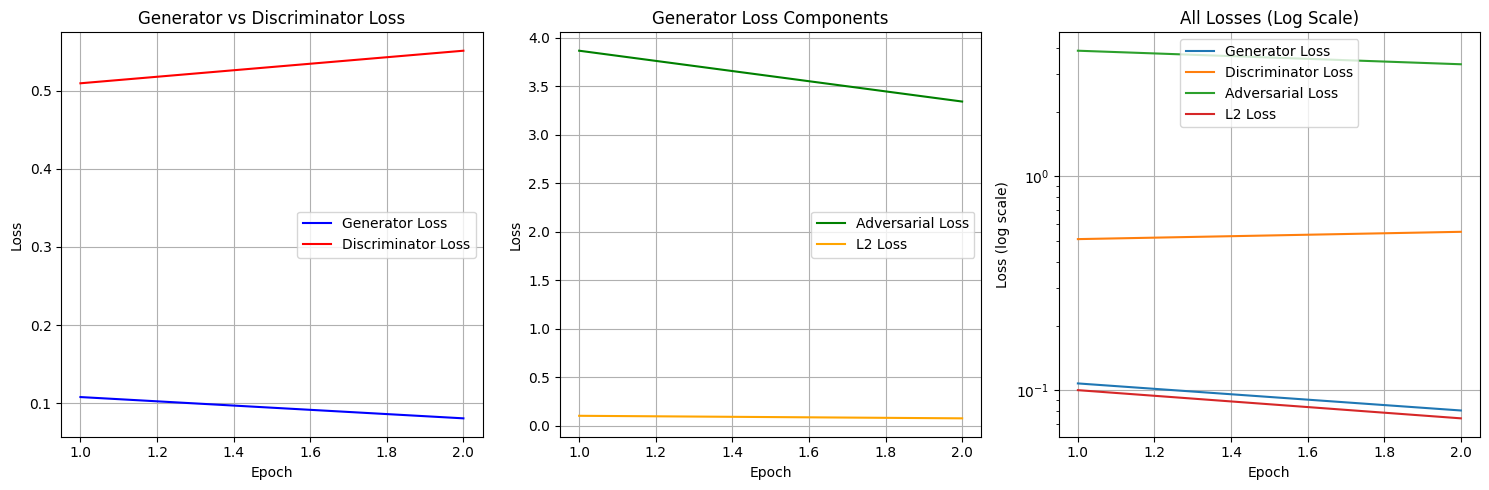

In [14]:
import matplotlib.pyplot as plt
import numpy as np

def plot_losses(G_losses, D_losses, G_D_losses, G_L2_losses):
    plt.figure(figsize=(15, 5))
    
    # Plot 1: Generator and Discriminator losses
    plt.subplot(1, 3, 1)
    plt.plot(range(1, len(G_losses) + 1), G_losses, label='Generator Loss', color='blue')
    plt.plot(range(1, len(D_losses) + 1), D_losses, label='Discriminator Loss', color='red')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Generator vs Discriminator Loss')
    plt.legend()
    plt.grid(True)
    
    # Plot 2: Generator loss components
    plt.subplot(1, 3, 2)
    plt.plot(range(1, len(G_D_losses) + 1), G_D_losses, label='Adversarial Loss', color='green')
    plt.plot(range(1, len(G_L2_losses) + 1), G_L2_losses, label='L2 Loss', color='orange')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Generator Loss Components')
    plt.legend()
    plt.grid(True)
    
    # Plot 3: All losses together (log scale might be helpful)
    plt.subplot(1, 3, 3)
    plt.semilogy(range(1, len(G_losses) + 1), G_losses, label='Generator Loss')
    plt.semilogy(range(1, len(D_losses) + 1), D_losses, label='Discriminator Loss')
    plt.semilogy(range(1, len(G_D_losses) + 1), G_D_losses, label='Adversarial Loss')
    plt.semilogy(range(1, len(G_L2_losses) + 1), G_L2_losses, label='L2 Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (log scale)')
    plt.title('All Losses (Log Scale)')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig('training_losses.png', dpi=300, bbox_inches='tight')
    plt.show()

# Call the plotting function after training
plot_losses(G_losses, D_losses, G_D_losses, G_L2_losses)

In [7]:
# importing the models : 
netG_path = "model/netG.pth"
netD_path = "model/netlocalD.pth"

netG = _netG(opt)
netD = _netlocalD(opt)
checkpoint_G = torch.load(netG_path, weights_only=True)
checkpoint_D = torch.load(netD_path, weights_only=True)

# Load only the state_dict part
netG.load_state_dict(checkpoint_G['state_dict'])
netD.load_state_dict(checkpoint_D['state_dict'])

<All keys matched successfully>

In [18]:

from PIL import Image
image_path = "datasets/image.jpeg"
pil_image = Image.open(image_path)
image_tensor = img_transfrom(pil_image)
image_tensor.unsqueeze(0).shape



torch.Size([1, 3, 128, 128])

In [23]:
from PIL import Image
import torchvision.utils as vutils
device = "cuda" if torch.cuda.is_available() else "cpu"
def fill(path) : 
    netG.eval()  # Set the model to evaluation mode
    with torch.no_grad():  # Disable gradient computation
        pil_image = Image.open(image_path)
        image_tensor = img_transfrom(pil_image)
        batch = image_tensor.unsqueeze(0)
        batch.data[:, 0, opt.imageSize//4 + opt.overlap : opt.imageSize// 4 + opt.imageSize // 2 - opt.overlap, opt.imageSize//4 + opt.overlap : opt.imageSize// 4 + opt.imageSize // 2 - opt.overlap] = 2*117.0/255 - 1.0
        batch.data[:, 1, opt.imageSize//4 + opt.overlap : opt.imageSize// 4 + opt.imageSize // 2 - opt.overlap, opt.imageSize//4 + opt.overlap : opt.imageSize// 4 + opt.imageSize // 2 - opt.overlap] = 2*104.0/255 - 1.0
        batch.data[:, 2, opt.imageSize//4 + opt.overlap : opt.imageSize// 4 + opt.imageSize // 2 - opt.overlap, opt.imageSize//4 + opt.overlap : opt.imageSize// 4 + opt.imageSize // 2 - opt.overlap] = 2*123.0/255 - 1.0
        
        fake = netG(batch)
        
        
        vutils.save_image(batch,f'result/train/cropped/cropped_train.png',
                          normalize=True, nrow=1)

        # Create and save reconstruction
        recon_image = batch.clone()
        recon_image[:, :, 32:96, 32:96] = fake  # Use integer division
        vutils.save_image(recon_image,f'result/train/recon/recon_test.png', 
                    normalize=True, nrow=1)
        print("Successfully saved the image")

In [24]:
image_path = "datasets/image.jpeg"
fill(image_path)

Successfully saved the image
